# 03. Category & Economics

**Notebook goal:** category level risk (which categories under/over perform on satisfaction and cancellation), the growth isn't reaching everywhere declining categories finding, and the freight economics story including the discovery finding that freight burden, ruled out overall, re emerges for expensive orders specifically.

**Source:** `analysis_master.csv`, `products_dataset.csv`, `order_items_dataset.csv`.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!pip install adjustText
from adjustText import adjust_text

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "font.size": 11,
})
ACCENT = "#2E5EAA"
ACCENT_WARN = "#C0392B"
NEUTRAL = "#B0B0B0"

In [2]:
df = pd.read_csv('analysis_master.csv')
delivered = df[df["is_delivered"] == True].copy()
print(f"Loaded {len(df):,} orders, {len(delivered):,} delivered")

Loaded 99,441 orders, 96,478 delivered


In [3]:
TOP_N = 15
top_categories = df["primary_category"].value_counts().head(TOP_N).index.tolist()
print(f"Top {TOP_N} categories by volume:")
print(top_categories)

Top 15 categories by volume:
['bed_bath_table', 'health_beauty', 'sports_leisure', 'computers_accessories', 'furniture_decor', 'housewares', 'watches_gifts', 'telephony', 'auto', 'toys', 'cool_stuff', 'garden_tools', 'perfumery', 'baby', 'electronics']


**Why top 15, not all 74:** Track B's original finding still applies here because 74 categories is a long tail, and a single chart trying to show all of them won't be legible (Week 8's small multiples principle only helps once the grid itself is a sane size). Every chart below that is category level uses this same top 15 cut, so results are comparable across charts.

## The category risk landscape: review score distributions, not just averages

A single average review score per category can hide differences in shape. Two categories with the same mean could have very different distributions (one consistently mediocre, another polarized between very happy and very unhappy customers). Small multiples let us check the actual shape for each category at once.


In [4]:
star_dist = (delivered[delivered["primary_category"].isin(top_categories)]
             .groupby("primary_category")["review_score"]
             .value_counts(normalize=True)
             .unstack()
             .reindex(columns=[1, 2, 3, 4, 5]) * 100)

cat_order = (delivered[delivered["primary_category"].isin(top_categories)]
             .groupby("primary_category")["review_score"].mean()
             .sort_values().index)
star_dist = star_dist.reindex(cat_order)
star_dist.round(1)

review_score,1,2,3,4,5
primary_category,,,,,
bed_bath_table,11.9,4.0,9.9,20.1,54.2
telephony,10.3,3.7,10.0,22.0,54.1
furniture_decor,11.1,3.7,8.8,19.0,57.4
computers_accessories,11.3,3.3,8.2,20.5,56.8
baby,10.6,3.2,8.7,18.6,58.9
watches_gifts,10.4,3.3,8.6,19.2,58.6
electronics,10.0,3.1,7.9,22.2,56.9
auto,9.7,3.1,7.7,21.3,58.3
garden_tools,8.9,2.8,7.9,20.1,60.3


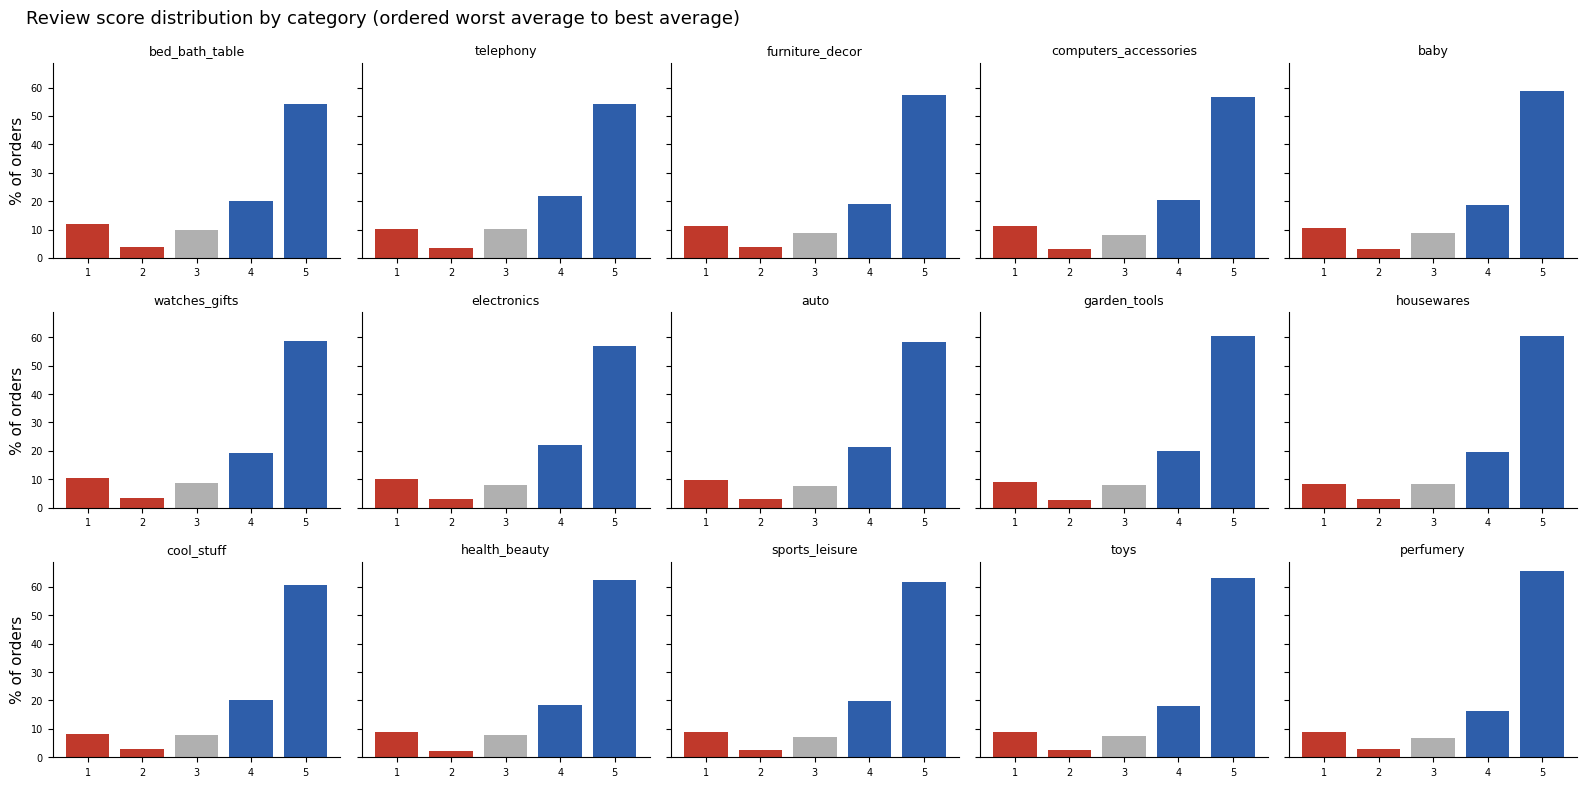

In [6]:
fig, axes = plt.subplots(3, 5, figsize=(16, 8), sharey=True)

for ax, cat in zip(axes.flat, cat_order):
    row = star_dist.loc[cat]
    colors = [ACCENT_WARN if s <= 2 else NEUTRAL if s == 3 else ACCENT for s in [1, 2, 3, 4, 5]]
    ax.bar([1, 2, 3, 4, 5], row.values, color=colors)
    ax.set_title(cat, fontsize=9)
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.tick_params(labelsize=7)

axes[0, 0].set_ylabel("% of orders")
axes[1, 0].set_ylabel("% of orders")
axes[2, 0].set_ylabel("% of orders")
fig.suptitle("Review score distribution by category (ordered worst average to best average)", fontsize=13, x=0.02, ha="left")
plt.tight_layout()
plt.show()

**Finding:** every category shares the same basic bimodal shape (a tall 5 star bar, a smaller but real 1 star bar, and thin middle).

- This isn't 15 different distribution shapes, it's the same shape at slightly different heights. That itself is informative: category doesn't change how people rate, mostly just how often they land on either end.

- `bed_bath_table` and `telephony` (top left, worst average) have visibly taller red (1 or 2 star) bars than `perfumery` or `toys` (bottom right, best average), but no category looks fundamentally different in kind. This tempers how much weight which category should get in the driver story. It shifts the balance a little, not the underlying pattern.

## Cancellation rate by category

A different kind of risk. Not did the customer end up unhappy, but did the order even complete. Uses all orders (not just delivered), since a canceled order is by definition not delivered.

In [7]:
cat_cancel = (df[df["primary_category"].isin(top_categories)]
              .groupby("primary_category")["is_canceled"]
              .agg(cancel_rate="mean", n="count")
              .sort_values("cancel_rate"))
cat_cancel["cancel_rate"] = cat_cancel["cancel_rate"] * 100
cat_cancel

,cancel_rate,n
primary_category,,
bed_bath_table,0.192967,9328
electronics,0.236686,2535
watches_gifts,0.356697,5607
garden_tools,0.374748,3469
furniture_decor,0.379147,6330
telephony,0.382867,4179
health_beauty,0.397682,8801
cool_stuff,0.416320,3603
perfumery,0.445151,3145


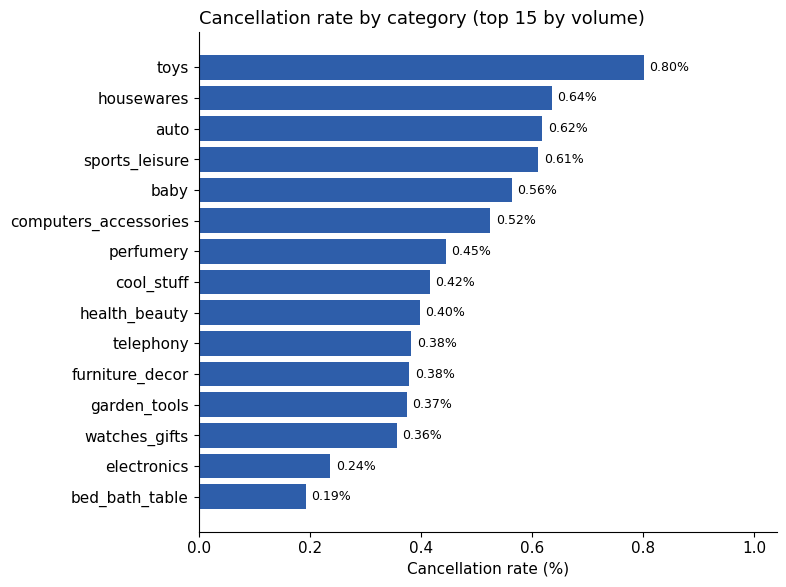

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(cat_cancel))
bars = ax.barh(y_pos, cat_cancel["cancel_rate"], color=ACCENT)
ax.set_yticks(y_pos)
ax.set_yticklabels(cat_cancel.index)
ax.bar_label(bars, fmt="%.2f%%", padding=4, fontsize=9)
ax.set_xlim(0, cat_cancel["cancel_rate"].max() * 1.3)
ax.set_xlabel("Cancellation rate (%)")
ax.set_title("Cancellation rate by category (top 15 by volume)", fontsize=13, loc="left")
plt.tight_layout()
plt.show()

**Finding:** a real but modest spread from 0.19% (`bed_bath_table`) to 0.80% (`toys`), roughly a 4x difference. `toys`, `housewares`, and `auto` sit consistently above the rest.

- Worth noting `toys` shows up twice in this notebook as a slightly elevated risk category (also one of the three categories declining despite overall growth, below) which is not proof the two are connected, but a pattern worth keeping in mind rather than treating as two unrelated facts.

## Categories declining despite overall marketplace growth

Notebook 01 showed total order volume grew steadily. Does every category share in that growth? Three categories, flagged by Track B, apparently don't.

In [9]:
EXCLUDE_MONTHS = ["2016-09", "2016-12", "2018-09", "2018-10"]
declining_categories = ["market_place", "toys", "consoles_games"]

monthly_cat = (df[~df["purchase_month"].isin(EXCLUDE_MONTHS) & df["primary_category"].isin(declining_categories)]
               .groupby(["purchase_month", "primary_category"])
               .size()
               .rename("n")
               .reset_index())
monthly_cat["period"] = np.where(monthly_cat["purchase_month"] < "2018-01", "pre-2018", "2018+")
monthly_cat.head()

,purchase_month,primary_category,n,period
0,2016-10,consoles_games,10,pre-2018
1,2016-10,market_place,7,pre-2018
2,2016-10,toys,25,pre-2018
3,2017-01,consoles_games,21,pre-2018
4,2017-01,market_place,6,pre-2018


In [10]:
period_avg = monthly_cat.groupby(["primary_category", "period"])["n"].mean().unstack()
period_avg["pct_change"] = (period_avg["2018+"] - period_avg["pre-2018"]) / period_avg["pre-2018"] * 100
period_avg

period,2018+,pre-2018,pct_change
primary_category,,,
consoles_games,48.25,51.615385,-6.520119
market_place,11.50,14.000000,-17.857143
toys,175.50,189.692308,-7.481752


These three categories have very different scales (`toys` runs in the hundreds per month, `market_place` in single digits), so they're shown as separate panels rather than one shared axis line chart otherwise `market_place`'s line would be a flat, invisible sliver at the bottom next to `toys`.

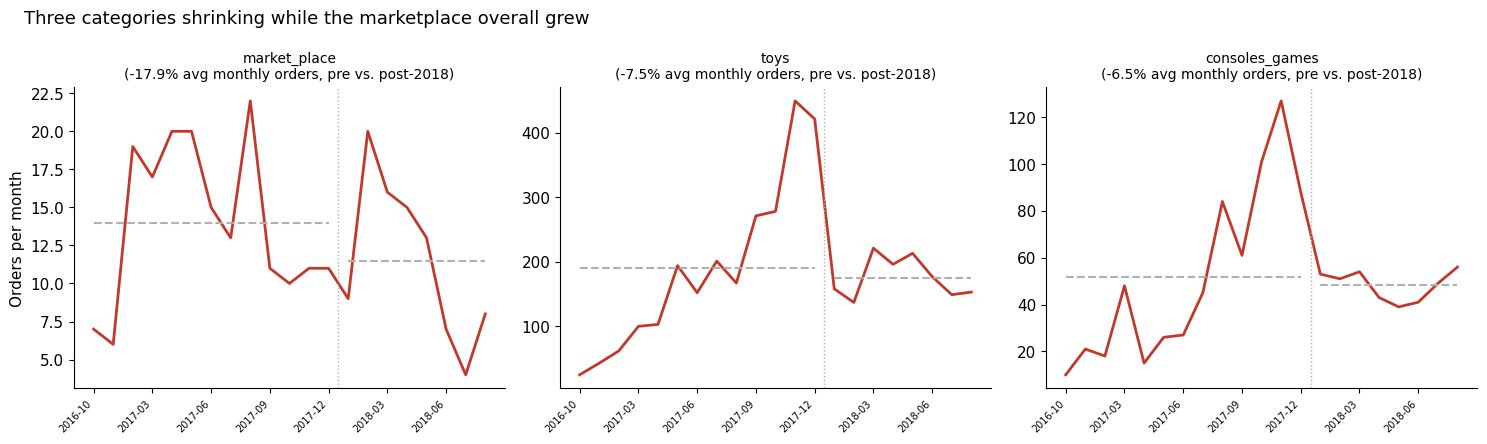

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=False)

for ax, cat in zip(axes, declining_categories):
    sub = monthly_cat[monthly_cat["primary_category"] == cat].reset_index(drop=True)
    x_pos = np.arange(len(sub))
    ax.plot(x_pos, sub["n"], color=ACCENT_WARN, linewidth=2)

    pre_avg = period_avg.loc[cat, "pre-2018"]
    post_avg = period_avg.loc[cat, "2018+"]
    split_idx = (sub["purchase_month"] < "2018-01").sum()
    ax.hlines(pre_avg, 0, split_idx - 1, color=NEUTRAL, linestyle="--", linewidth=1.5)
    ax.hlines(post_avg, split_idx, len(sub) - 1, color=NEUTRAL, linestyle="--", linewidth=1.5)
    ax.axvline(split_idx - 0.5, color=NEUTRAL, linestyle=":", linewidth=1)

    pct = period_avg.loc[cat, "pct_change"]
    ax.set_title(f"{cat}\n({pct:+.1f}% avg monthly orders, pre vs. post-2018)", fontsize=10)
    ax.set_xticks(x_pos[::3])
    ax.set_xticklabels(sub["purchase_month"].iloc[::3], rotation=45, ha="right", fontsize=7)

axes[0].set_ylabel("Orders per month")
fig.suptitle("Three categories shrinking while the marketplace overall grew", fontsize=13, x=0.02, ha="left")
plt.tight_layout()
plt.show()

**Finding:** all three show a visibly lower average after the 2018 boundary (dashed reference lines) than before it.

-  `market_place` down 17.9%, `toys` down 7.5%, `consoles_games` down 6.5% on average monthly volume.

- This is a genuinely different kind of finding than everything else in this notebook: it's not about quality (review score, cancellation) but about demand shrinking in specific categories while the marketplace as a whole grew which is worth a distinct callout in the final report as a where growth isn't reaching signal, not folded into the satisfaction risk narrative.

(Note: these percentages are computed directly from `analysis_master.csv` using average monthly order count, pre vs. post 2018 which are close to, but not identical to, Track B's originally reported -15.8%/-5.1%/-4.1%, since Track B's original pass used the raw `order_items` table at a slightly different grain. Both point the same direction and are consistent findings; the exact percentage depends on which table/grain you compute from, an example of Week 4's which level are you counting at lesson resurfacing.)

## Beyond the 3 decliners: how did ALL major categories' rank shift?

The three categories flagged above are declining in absolute volume but do other categories rise to fill that space, and does the picture change if we look at rank among the top categories rather than raw counts? Restricted to the top 12 categories by volume (so `market_place` and `consoles_games`, which are too small to place among these, aren't part of this specific view this chart complements, not replaces, the finding above).

In [12]:
top12_cats = df["primary_category"].value_counts().head(12).index.tolist()
d_rank = df[~df["purchase_month"].isin(EXCLUDE_MONTHS) & df["primary_category"].isin(top12_cats)].copy()
d_rank["period"] = np.where(d_rank["purchase_month"] < "2018-01", "pre-2018", "2018+")

n_months_pre = d_rank[d_rank["period"] == "pre-2018"]["purchase_month"].nunique()
n_months_post = d_rank[d_rank["period"] == "2018+"]["purchase_month"].nunique()

avg_monthly = d_rank.groupby(["primary_category", "period"]).size().unstack()
avg_monthly["pre-2018"] = avg_monthly["pre-2018"] / n_months_pre
avg_monthly["2018+"] = avg_monthly["2018+"] / n_months_post
avg_monthly["rank_pre"] = avg_monthly["pre-2018"].rank(ascending=False)
avg_monthly["rank_post"] = avg_monthly["2018+"].rank(ascending=False)
avg_monthly.sort_values("rank_pre")

period,2018+,pre-2018,rank_pre,rank_post
primary_category,,,,
bed_bath_table,609.625,342.384615,1.0,2.0
sports_leisure,504.250,280.692308,2.0,4.0
health_beauty,672.250,263.230769,3.0,1.0
furniture_decor,390.625,246.461538,4.0,7.0
computers_accessories,505.125,202.230769,5.0,3.0
toys,175.500,189.692308,6.0,11.0
housewares,422.500,187.769231,7.0,6.0
cool_stuff,175.125,169.384615,8.0,12.0
watches_gifts,435.750,163.153846,9.0,5.0


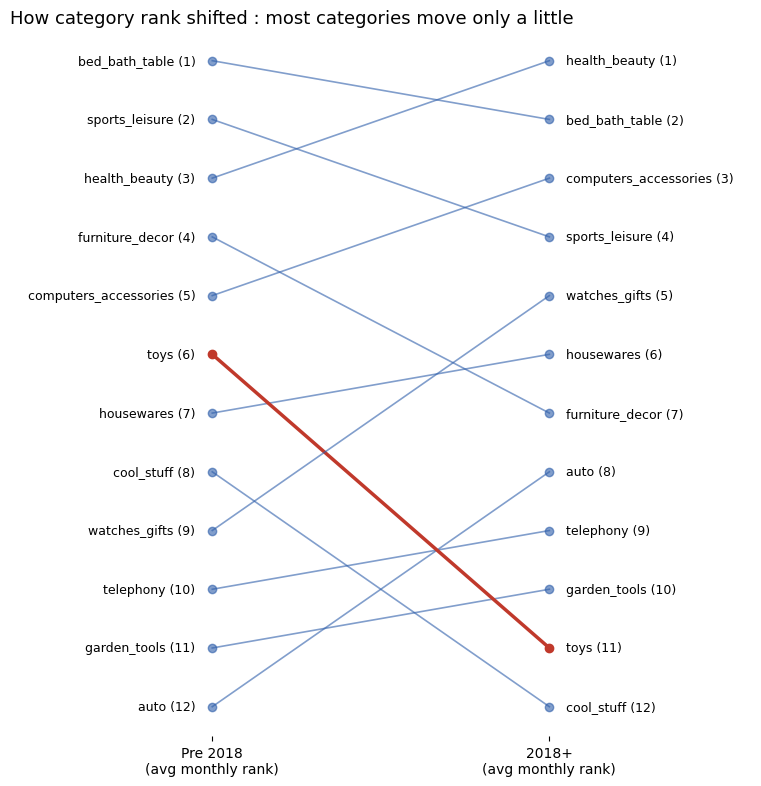

In [13]:
fig, ax = plt.subplots(figsize=(8, 8))
DECLINING = ["toys", "consoles_games"]

for cat, row in avg_monthly.iterrows():
    color = ACCENT_WARN if cat in DECLINING else ACCENT
    lw = 2.5 if cat in DECLINING else 1.2
    alpha = 1.0 if cat in DECLINING else 0.6
    ax.plot([0, 1], [row["rank_pre"], row["rank_post"]], marker="o", color=color, linewidth=lw, alpha=alpha)
    ax.text(-0.05, row["rank_pre"], f"{cat} ({int(row['rank_pre'])})", ha="right", va="center", fontsize=9)
    ax.text(1.05, row["rank_post"], f"{cat} ({int(row['rank_post'])})", ha="left", va="center", fontsize=9)

ax.set_xlim(-0.6, 1.6)
ax.set_ylim(12.5, 0.5)  # inverted: rank 1 at top
ax.set_xticks([0, 1])
ax.set_xticklabels(["Pre 2018\n(avg monthly rank)", "2018+\n(avg monthly rank)"], fontsize=10)
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title("How category rank shifted : most categories move only a little", fontsize=13, loc="left")
plt.tight_layout()
plt.show()

**Finding:** most categories shift only 1 to 2 rank positions which is a fairly stable landscape overall.

- `toys` is the most dramatic mover among the top 12, dropping 5 places (6th to 11th), and `cool_stuff` drops 4 places (8th to 12th).

- A decline not previously flagged in the original 3 category finding, since that analysis looked at percentage change in raw volume, not rank.

- On the other end, `health_beauty` rises from 3rd to 1st, and `watches_gifts` and `auto` each climb 4 places.

- Worth a footnote in the report: the declining categories story has at least one more real member (`cool_stuff`) than originally identified, found here by looking at the data from a rank perspective rather than a percent change perspective.

## Why does freight vary so much? Physical size, not category or seller

Before asking whether freight burden relates to satisfaction, it's worth confirming why freight cost varies at all. Is it driven by a product's actual physical size, or something more arbitrary? This needs two raw files not present in `analysis_master.csv`: `order_items_dataset.csv` (the bridge table linking a product to the freight actually charged) and `products_dataset.csv` (weight and dimensions).

In [14]:
order_items = pd.read_csv("order_items_dataset.csv")
products = pd.read_csv("products_dataset.csv")

size_freight = order_items.merge(products, on="product_id", how="left").dropna(
    subset=["product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
)
size_freight["volume_cm3"] = (size_freight["product_length_cm"] *
                               size_freight["product_height_cm"] *
                               size_freight["product_width_cm"])
print(f"{len(size_freight):,} items with known weight and dimensions")

112,632 items with known weight and dimensions


Both weight and freight are heavily right skewed (a handful of very large/heavy items alongside a mass of small ones). A log view is needed to see the relationship clearly. 383 items with `freight_value == 0` and 4 with `product_weight_g == 0` are excluded from the plot only, since neither can be shown on a log scale (log of zero is undefined) and the correlations themselves are computed on the full set.

In [15]:
weight_corr = size_freight["product_weight_g"].corr(size_freight["freight_value"])
volume_corr = size_freight["volume_cm3"].corr(size_freight["freight_value"])
print(f"Correlation, weight vs. freight: {weight_corr:.3f}")
print(f"Correlation, volume vs. freight: {volume_corr:.3f}")

plot_df = size_freight[(size_freight["freight_value"] > 0) & (size_freight["product_weight_g"] > 0)]

Correlation, weight vs. freight: 0.610
Correlation, volume vs. freight: 0.587


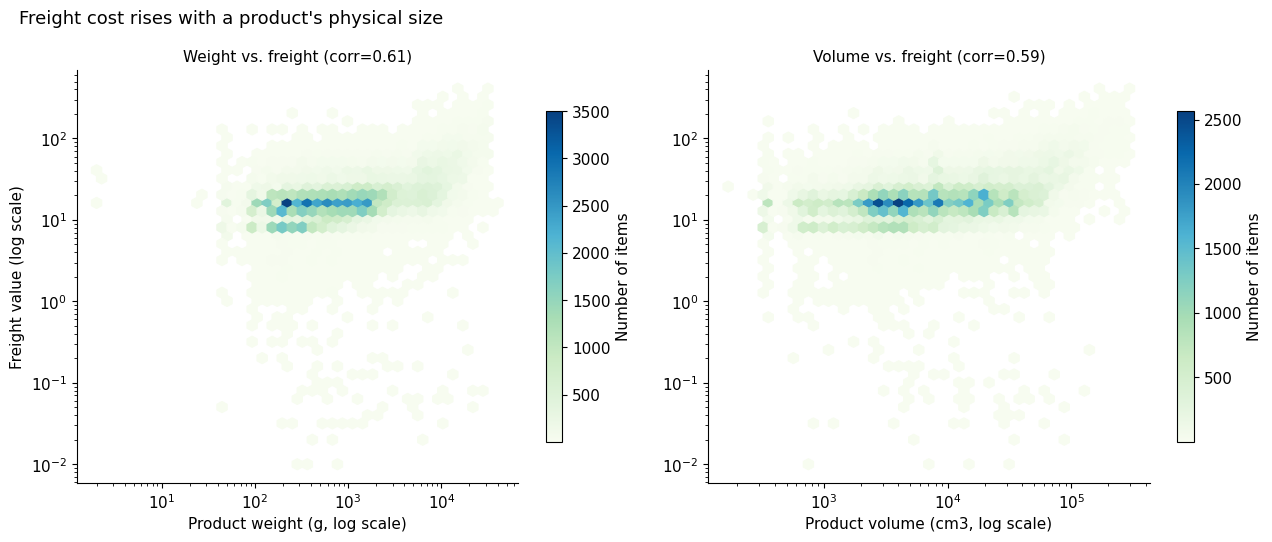

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

hb1 = axes[0].hexbin(plot_df["product_weight_g"], plot_df["freight_value"],
                      gridsize=40, cmap="GnBu", mincnt=1, xscale="log", yscale="log")
axes[0].set_xlabel("Product weight (g, log scale)")
axes[0].set_ylabel("Freight value (log scale)")
axes[0].set_title(f"Weight vs. freight (corr={weight_corr:.2f})", fontsize=11)

hb2 = axes[1].hexbin(plot_df["volume_cm3"], plot_df["freight_value"],
                      gridsize=40, cmap="GnBu", mincnt=1, xscale="log", yscale="log")
axes[1].set_xlabel("Product volume (cm3, log scale)")
axes[1].set_title(f"Volume vs. freight (corr={volume_corr:.2f})", fontsize=11)

for ax, hb in zip(axes, [hb1, hb2]):
    cbar = plt.colorbar(hb, ax=ax, shrink=0.8)
    cbar.set_label("Number of items")

fig.suptitle("Freight cost rises with a product's physical size", fontsize=13, x=0.02, ha="left")
plt.tight_layout()
plt.show()

**Finding:** both weight (0.61) and volume (0.59) correlate moderately to strongly with freight cost.

- Confirmed directly from the raw files, and matching Track B's originally reported figures almost exactly.

- The density visibly climbs up and to the right in both panels: freight pricing is driven by real physical size, not an arbitrary or purely price based charge.

- This is useful context for the freight ratio findings elsewhere in this notebook when a category or price tier shows an unusually high freight ratio, physical bulk is the most likely underlying reason, not inconsistent or unfair pricing.

## Freight economics: does freight burden relate to satisfaction, by category?

Track D's original finding was that freight ratio doesn't meaningfully predict review score overall. Does that hold up category by category, or do some categories carry both high freight and low satisfaction together?

In [17]:
cat_freight = (delivered[delivered["primary_category"].isin(top_categories)]
               .groupby("primary_category")
               .agg(avg_freight_ratio=("freight_ratio", "mean"),
                    avg_review=("review_score", "mean"),
                    n=("order_id", "count")))
cat_freight.sort_values("avg_freight_ratio")

,avg_freight_ratio,avg_review,n
primary_category,,,
watches_gifts,0.164638,4.122839,5478
cool_stuff,0.206696,4.229869,3530
perfumery,0.256529,4.268061,3069
toys,0.259724,4.240021,3788
bed_bath_table,0.271202,4.007481,9184
health_beauty,0.278364,4.232870,8613
sports_leisure,0.281779,4.235065,7493
baby,0.285392,4.121577,2761
computers_accessories,0.297925,4.082549,6512


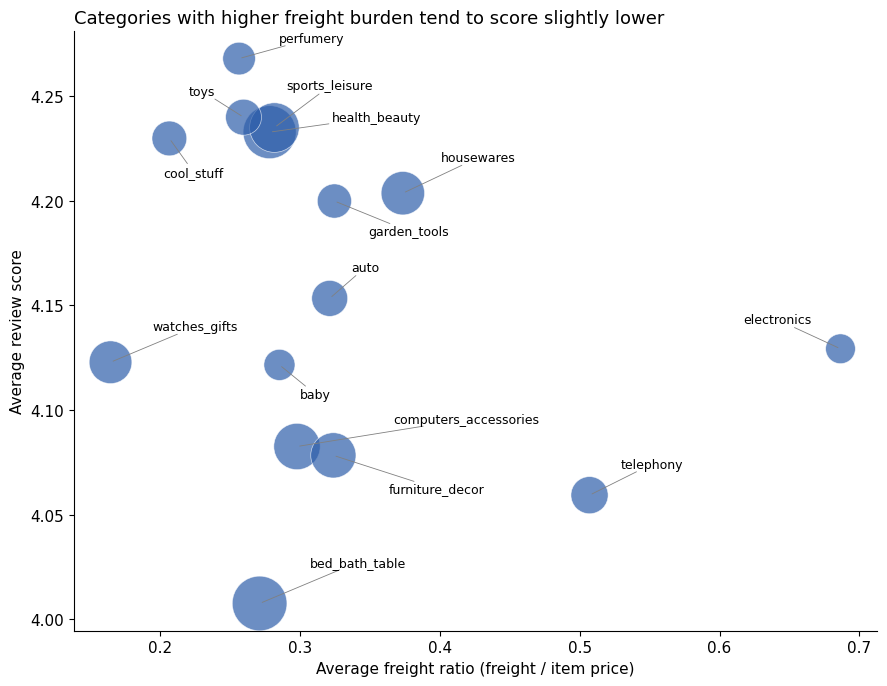

In [18]:
fig, ax = plt.subplots(figsize=(9, 7))
sizes = cat_freight["n"] / cat_freight["n"].max() * 1500 + 50
scatter = ax.scatter(cat_freight["avg_freight_ratio"], cat_freight["avg_review"],
                      s=sizes, color=ACCENT, alpha=0.7, edgecolors="white", linewidth=0.5)

texts = [ax.text(row["avg_freight_ratio"], row["avg_review"], cat, fontsize=9)
         for cat, row in cat_freight.iterrows()]
adjust_text(texts, ax=ax, objects=scatter, force_text=(0.4, 0.5), expand=(1.4, 1.6),
            arrowprops=dict(arrowstyle="-", color="gray", lw=0.6))

ax.set_xlabel("Average freight ratio (freight / item price)")
ax.set_ylabel("Average review score")
ax.set_title("Categories with higher freight burden tend to score slightly lower", fontsize=13, loc="left")
plt.tight_layout()
plt.show()

In [19]:
print(f"Correlation across categories: {cat_freight['avg_freight_ratio'].corr(cat_freight['avg_review']):.3f}")

Correlation across categories: -0.265


**Finding:** at the category level, there's a real negative relationship (-0.265) that wasn't visible in Track D's order level ruled out finding.

- `electronics` and `telephony` combine the highest freight ratios with below median review scores.

- This doesn't contradict Track D's original finding so much as sit at a different level of aggregation: individual orders' freight ratio barely matters (confirmed again below), but categories that structurally run high freight ratios (small, light, individually priced electronics accessories where shipping is a big fraction of a low item price) do trend toward lower satisfaction. Worth stating both levels in the report rather than picking one.

## Discovery finding: freight ratio matters more for expensive orders

Track D's order level freight ratio doesn't predict review score finding was checked again here with one refinement: does it hold the same way for a 20 Real order as a 200 Real (currency in R$) order? Orders are split into four price quartiles, and within each, into four freight ratio quartiles.

In [20]:

fr = delivered.dropna(subset=["order_item_value", "freight_ratio"]).copy()
fr["price_tier"] = pd.qcut(fr["order_item_value"], 4, labels=["Q1 (cheapest)", "Q2", "Q3", "Q4 (priciest)"])
fr["freight_bucket"] = pd.qcut(fr["freight_ratio"], 4, labels=["Lowest", "Low-mid", "High-mid", "Highest"])

interaction = fr.groupby(["price_tier", "freight_bucket"], observed=True).agg(
    mean=("review_score", "mean"), n=("review_score", "count")
)
interaction

mean      n
price_tier    freight_bucket                 
Q1 (cheapest) Lowest          2.687500     16
              Low-mid         4.384615   1144
              High-mid        4.316562   5585
              Highest         4.171695  17467
Q2            Lowest          4.265070   1211
              Low-mid         4.226081   7170
              High-mid        4.187658  11489
              Highest         3.993020   3868
Q3            Lowest          4.225568   6641
              Low-mid         4.189409  11330
              High-mid        4.012163   4604
              Highest         3.960268   1938
Q4 (priciest) Lowest          4.171295  16095
              Low-mid         3.957765   4475
              High-mid        3.843544   2122
              Highest         3.729690    677

**A small sample flag before plotting:** the cheapest price tier's Lowest freight bucket cell has only 16 orders (visible in the table above) which is nowhere near enough to trust. It's included in the chart below for completeness but explicitly marked, rather than silently plotted at face value alongside cells with thousands of orders (always check `n` before trusting a rate).

/tmp/ipykernel_2131/1007522456.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=30, ha="right", fontsize=8)
/tmp/ipykernel_2131/1007522456.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=30, ha="right", fontsize=8)
/tmp/ipykernel_2131/1007522456.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=30, ha="right", fontsize=8)
/tmp/ipykernel_2131/1007522456.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub.index, rotation=30, ha="right", fontsize=8)


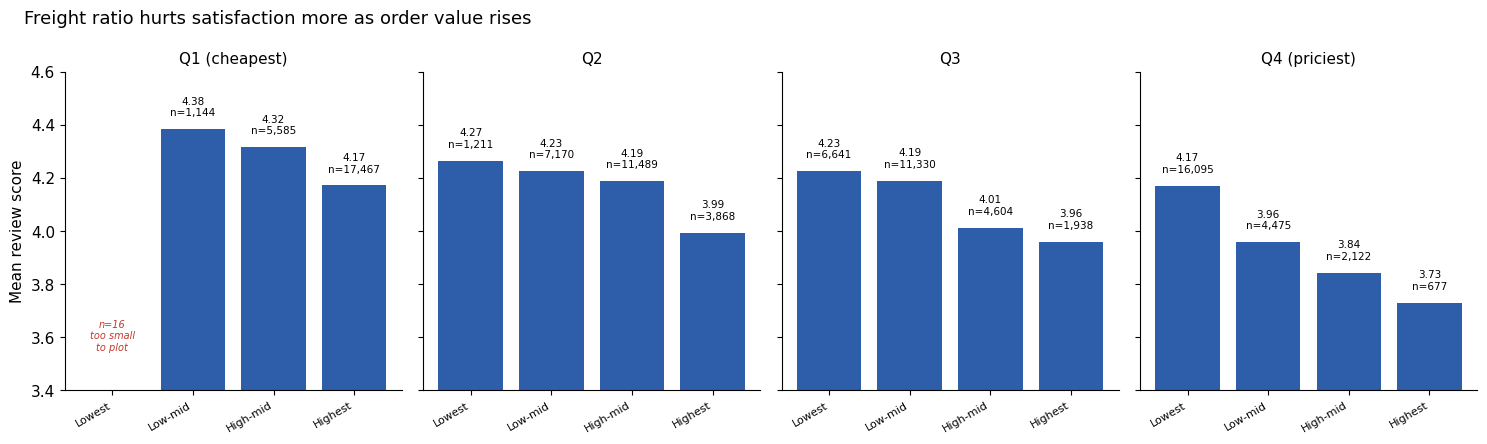

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.5), sharey=True)
price_tiers = ["Q1 (cheapest)", "Q2", "Q3", "Q4 (priciest)"]
MIN_N = 100

for ax, tier in zip(axes, price_tiers):
    sub = interaction.loc[tier]
    plot_values = [v if n >= MIN_N else 0 for v, n in zip(sub["mean"], sub["n"])]
    bars = ax.bar(sub.index, plot_values, color=ACCENT)
    for bar, (mean, n) in zip(bars, zip(sub["mean"], sub["n"])):
        if n >= MIN_N:
            ax.text(bar.get_x() + bar.get_width()/2, mean + 0.05, f"{mean:.2f}\nn={n:,}",
                    ha="center", fontsize=7.5)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, 3.55, f"n={n}\ntoo small\nto plot",
                    ha="center", fontsize=7, color=ACCENT_WARN, style="italic")
    ax.set_title(tier, fontsize=11)
    ax.set_xticklabels(sub.index, rotation=30, ha="right", fontsize=8)

axes[0].set_ylabel("Mean review score")
axes[0].set_ylim(3.4, 4.6)
fig.suptitle("Freight ratio hurts satisfaction more as order value rises", fontsize=13, x=0.02, ha="left")
plt.tight_layout()
plt.show()

In [22]:
cheap = fr[fr["price_tier"] == "Q1 (cheapest)"]
expensive = fr[fr["price_tier"] == "Q4 (priciest)"]
print(f"Cheapest quartile:  corr(freight_ratio, review) = {cheap['freight_ratio'].corr(cheap['review_score']):.3f}")
print(f"Priciest quartile:  corr(freight_ratio, review) = {expensive['freight_ratio'].corr(expensive['review_score']):.3f}")

Cheapest quartile:  corr(freight_ratio, review) = -0.054
Priciest quartile:  corr(freight_ratio, review) = -0.089


**Finding:** within the cheapest quarter of orders, freight ratio barely matters (correlation -0.054, nearly flat bars above), matching Track D's original ruled out conclusion.

- But within the priciest quarter, the pattern is clear and monotonic: review score drops from 4.17 to 3.73 as freight ratio rises, and the correlation nearly doubles (-0.089), with every cell here resting on a solid sample (677 to 16,095 orders).

- This nuances rather than overturns the original finding. High shipping cost seems to sting more on a big ticket purchase, possibly because it disrupts the premium purchase feeling more than it does on an already cheap item. Genuinely speculative on the why; the that is solid.

## The zero freight rows mystery now resolved

Track B flagged 383 order item rows with `freight_value == 0` as an open question: does this cluster by category/seller (a real pattern), or is it scattered (a data quirk)? `analysis_master.csv` carries 338 such rows at its own grain (order level, primary item) which is close to Track B's original count, with the small difference explained by the change in grain. This is checked directly below rather than left open.


In [23]:
zero_freight = df[df["freight_value"] == 0]
print(f"Zero-freight orders: {len(zero_freight)}")
print(f"Unique sellers responsible for all of them: {zero_freight['seller_id'].nunique()}")

Zero-freight orders: 338
Unique sellers responsible for all of them: 8


In [24]:
by_seller = zero_freight["seller_id"].value_counts()
by_seller

,count
seller_id,
7d13fca15225358621be4086e1eb0964,146
955fee9216a65b617aa5c0531780ce60,83
4869f7a5dfa277a7dca6462dcf3b52b2,56
1f50f920176fa81dab994f9023523100,40
37be5a7c751166fbc5f8ccba4119e043,9
c826c40d7b19f62a09e2d7c5e7295ee2,2
cc419e0650a3c5ba77189a1882b7556a,1
8581055ce74af1daba164fdbd55a40de,1


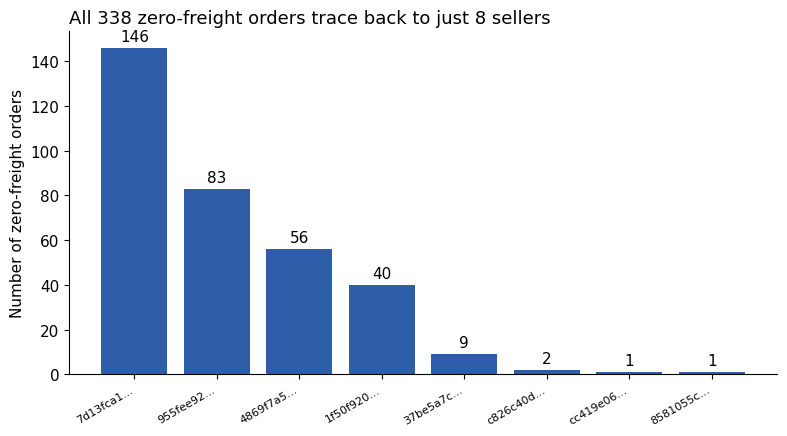

In [25]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(range(len(by_seller)), by_seller.values, color=ACCENT)
ax.bar_label(bars, padding=3)
ax.set_xticks(range(len(by_seller)))
ax.set_xticklabels([s[:8] + "..." for s in by_seller.index], rotation=30, ha="right", fontsize=8)
ax.set_ylabel("Number of zero-freight orders")
ax.set_title("All 338 zero-freight orders trace back to just 8 sellers", fontsize=13, loc="left")
plt.tight_layout()
plt.show()

**Finding:** all 338 zero freight orders come from just 8 sellers (out of 3,085 total), and one seller alone accounts for 146 of them (43%).

- This isn't a scattered data entry quirk, it's a real, seller specific pattern, most probably a handful of sellers who structurally bundle shipping into the item price rather than charging it separately (or a free shipping promotional listing style).

- Since it's concentrated rather than random, it's safe to leave these rows as legitimate zero values rather than treating them as missing/erroneous data but worth a one line footnote in the report closing out a limitation Track B explicitly left open.

## Summary

1. Category doesn't change the shape of the review score distribution (always bimodal) — mostly shifts how often orders land at either end.
2. Cancellation rate varies modestly by category (0.19% to 0.80%); `toys` stands out as elevated on both cancellation and the declining demand finding below.
3. Three categories (`market_place`, `toys`, `consoles_games`) are shrinking in absolute volume even as the marketplace overall grows which is a demand story, not a quality story.
4. Freight ratio's relationship to satisfaction depends on aggregation level: barely matters per order overall, but categories that structurally run high freight ratios do trend toward lower average scores, and the effect concentrates specifically in expensive orders.
5. The zero freight rows question Track B left open is resolved: it's 8 specific sellers, not a scattered data issue.
6. Freight cost is genuinely driven by physical size (weight/volume), confirmed directly from the raw product and order item data, not arbitrary or category based pricing.